<a href="https://colab.research.google.com/github/arya2005-tech/CSL701-CS44-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Arya Abhiram Prabhudesai      Roll No.:CS44

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


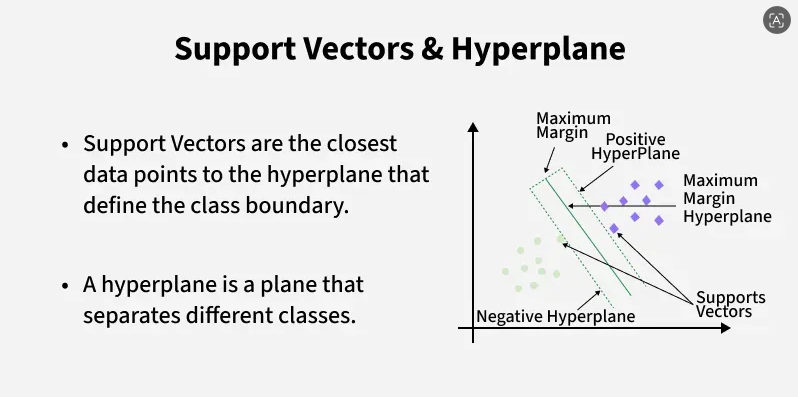
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(url)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


# Task 2: Explore the Dataset

In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['species'].value_counts())

print("\nStatistical summary:")
print(df.describe())

Shape of dataset:
(150, 5)

Column names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 1.0
SVM Accuracy (%): 100.0


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


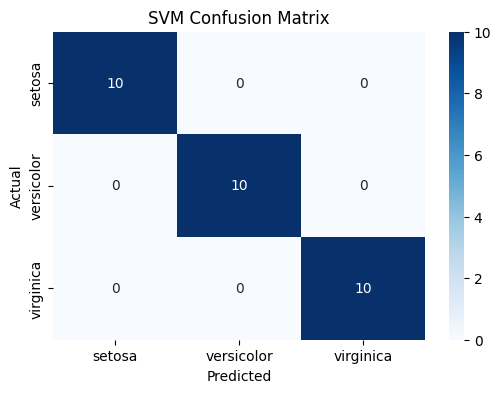

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

In [ ]:
X_2d = df[['petal_length', 'petal_width']]
y_2d = df['species']

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

svm_2d = SVC(kernel='linear')

svm_2d.fit(X_train_2d_scaled, y_train_2d)

print("2-D Linear SVM trained successfully.")

2-D Linear SVM trained successfully.


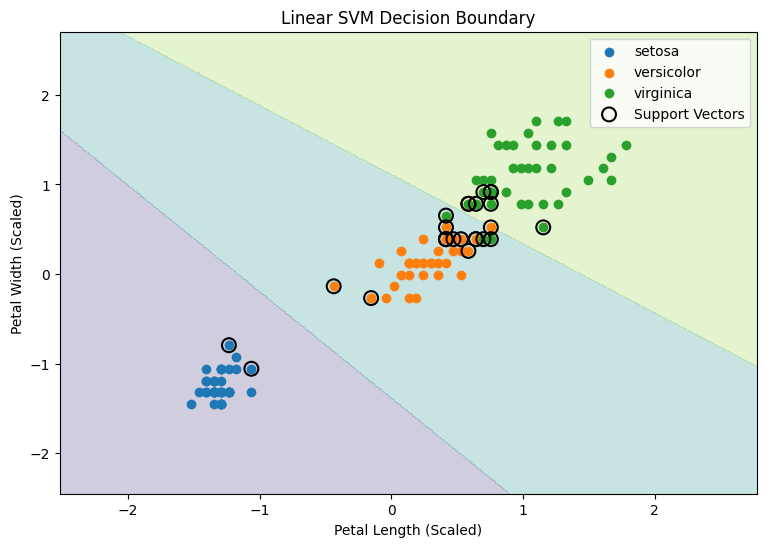

In [ ]:
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = svm_2d.predict(grid)

class_numbers = pd.factorize(y_2d)[0]
class_names = list(pd.factorize(y_2d)[1])

Z_numeric = pd.Categorical(
    Z,
    categories=class_names
).codes

Z_numeric = Z_numeric.reshape(xx.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25,
    levels=np.arange(len(class_names) + 1) - 0.5,
    cmap='viridis'
)

for i, class_name in enumerate(class_names):
    mask = y_train_2d == class_name
    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

support_vectors = svm_2d.support_vectors_

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [ ]:
log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train_2d_scaled, y_train_2d)

y_pred_log = log_model.predict(X_test_2d_scaled)

print("Logistic Regression Predictions:")
print(y_pred_log)

Logistic Regression Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


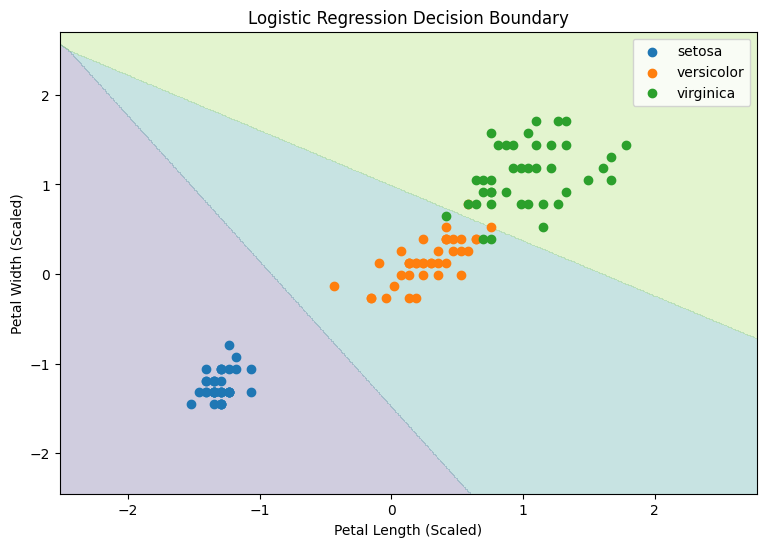

In [ ]:
Z_log = log_model.predict(grid)

Z_log_numeric = pd.Categorical(
    Z_log,
    categories=class_names
).codes

Z_log_numeric = Z_log_numeric.reshape(xx.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_log_numeric,
    alpha=0.25,
    levels=np.arange(len(class_names) + 1) - 0.5,
    cmap='viridis'
)

for class_name in class_names:
    mask = y_train_2d == class_name

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

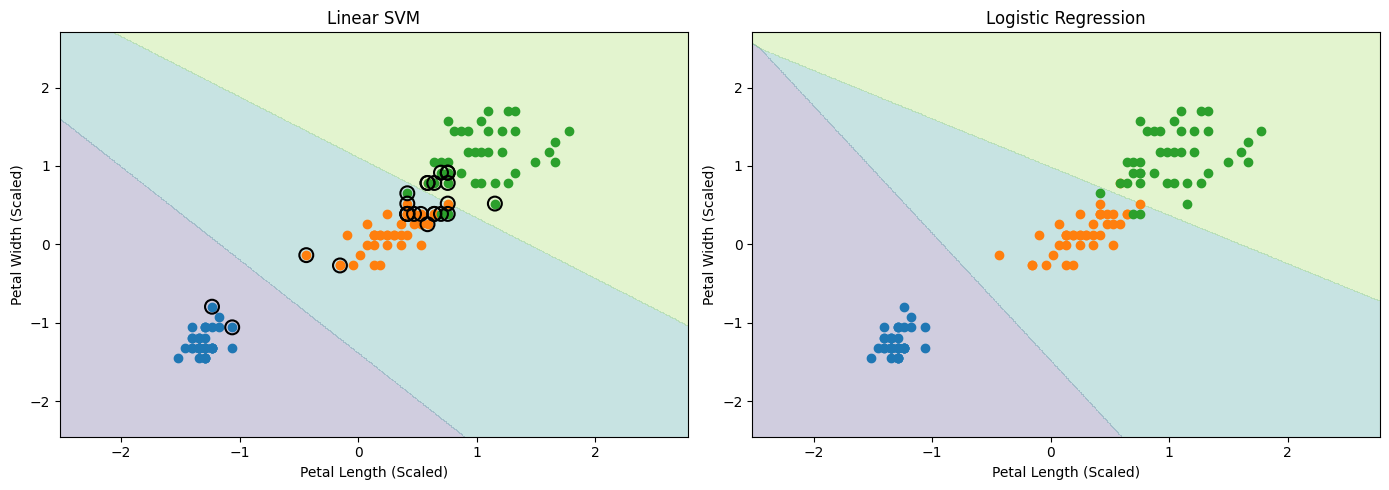

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM
axes[0].contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25,
    levels=np.arange(len(class_names) + 1) - 0.5,
    cmap='viridis'
)

for class_name in class_names:
    mask = y_train_2d == class_name

    axes[0].scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

axes[0].scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")

# Logistic Regression
axes[1].contourf(
    xx,
    yy,
    Z_log_numeric,
    alpha=0.25,
    levels=np.arange(len(class_names) + 1) - 0.5,
    cmap='viridis'
)

for class_name in class_names:
    mask = y_train_2d == class_name

    axes[1].scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")

plt.tight_layout()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:

log_accuracy = accuracy_score(y_test_2d, y_pred_log)

In [ ]:
y_test_2d = y_test_2d

In [ ]:
svm_accuracy_2d = accuracy_score(y_test_2d, svm_2d.predict(X_test_2d_scaled))

log_accuracy = accuracy_score(y_test_2d, y_pred_log)

print("Linear SVM Accuracy:", svm_accuracy_2d)
print("Linear SVM Accuracy (%):", svm_accuracy_2d * 100)

print("\nLogistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Accuracy (%):", log_accuracy * 100)

Linear SVM Accuracy: 0.9333333333333333
Linear SVM Accuracy (%): 93.33333333333333

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333


SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


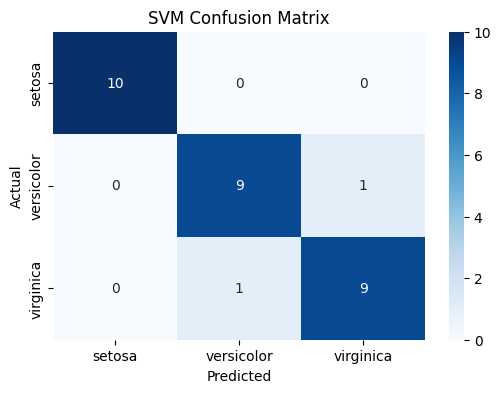

In [ ]:
svm_pred_2d = svm_2d.predict(X_test_2d_scaled)

cm_svm_2d = confusion_matrix(y_test_2d, svm_pred_2d)

print("SVM Confusion Matrix:")
print(cm_svm_2d)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm_2d,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


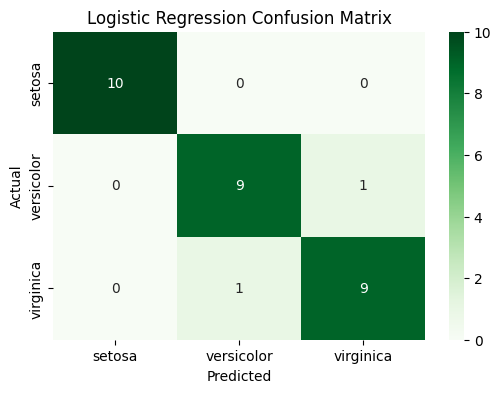

In [ ]:
cm_log = confusion_matrix(y_test_2d, y_pred_log)

print("Logistic Regression Confusion Matrix:")
print(cm_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
print("========== SVM CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_2d,
        svm_pred_2d
    )
)

print("========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_2d,
        y_pred_log
    )
)

========== SVM CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Logistic Regression"
    ],
    "Accuracy": [
        svm_accuracy_2d,
        log_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

print(comparison)

                 Model  Accuracy  Accuracy (%)
0           Linear SVM  0.933333     93.333333
1  Logistic Regression  0.933333     93.333333


# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.